#  Práctica: Creación e Implementación de un Data Warehouse

En este notebook se realiza la conexión a PostgreSQL, la creación de datos simulados, la carga al Data Warehouse y el análisis mediante consultas y visualizaciones.

Autor:Karol Yazmin Aguilar Hernandez

In [5]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np
import random
from sqlalchemy import create_engine
import psycopg2
import matplotlib.pyplot as plt

In [2]:
!pip install matplotlib

In [3]:
!pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 5.6 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 4.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   --------------------

In [4]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 6.7 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 4.9 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.9 MB/s  0:00:00


In [6]:
usuario = "postgres"
password = "tomoe"
host = "localhost"
puerto = "5432"
database = "dw_ventas"

engine = create_engine(
    f"postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{database}"
)

print("Conexión exitosa a PostgreSQL")

Conexión exitosa a PostgreSQL


In [7]:
clientes = pd.DataFrame({
    'nombre': ['Giovani', 'Keyla', 'Sandra', 'Adan', 'Martha'],
    'genero': ['M', 'F', 'F', 'M', 'F'],
    'edad': [25, 30, 22, 28, 35]
})

clientes

,nombre,genero,edad
0,Giovani,M,25
1,Keyla,F,30
2,Sandra,F,22
3,Adan,M,28
4,Martha,F,35


In [8]:
productos = pd.DataFrame({
    'producto': ['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Audífonos'],
    'categoria': ['Computo', 'Accesorios', 'Accesorios', 'Computo', 'Audio'],
    'precio': [15000, 250, 600, 8500, 800]
})

productos

,producto,categoria,precio
0,Laptop,Computo,15000
1,Mouse,Accesorios,250
2,Teclado,Accesorios,600
3,Monitor,Computo,8500
4,Audífonos,Audio,800


In [9]:
regiones = pd.DataFrame({
    'region': ['Norte', 'Centro', 'Sur', 'Occidente', 'Bajío'],
    'ciudad': ['Monterrey', 'Ciudad de México', 'Mérida', 'Guadalajara', 'Querétaro']
})

regiones

,region,ciudad
0,Norte,Monterrey
1,Centro,Ciudad de México
2,Sur,Mérida
3,Occidente,Guadalajara
4,Bajío,Querétaro


In [11]:
fechas = pd.date_range(start='2026-06-02', periods=12, freq='M')

tiempo = pd.DataFrame({
    'fecha': fechas,
    'mes': fechas.strftime('%B'),
    'anio': fechas.year
})

tiempo

C:\Users\Yazmin Aguilar\AppData\Local\Temp\ipykernel_28032\3007212502.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start='2026-06-02', periods=12, freq='M')


,fecha,mes,anio
0,2026-06-30,June,2026
1,2026-07-31,July,2026
2,2026-08-31,August,2026
3,2026-09-30,September,2026
4,2026-10-31,October,2026
5,2026-11-30,November,2026
6,2026-12-31,December,2026
7,2027-01-31,January,2027
8,2027-02-28,February,2027
9,2027-03-31,March,2027


In [12]:
ventas = []
for i in range(50):
    id_cliente = random.randint(1, len(clientes))
    id_producto = random.randint(1, len(productos))
    id_region = random.randint(1, len(regiones))
    id_tiempo = random.randint(1, len(tiempo))
    cantidad = random.randint(1, 5)

    precio = productos.loc[id_producto - 1, 'precio']
    total_venta = cantidad * precio
    ventas.append([
        id_cliente,
        id_producto,
        id_region,
        id_tiempo,
        cantidad,
        total_venta
    ])

fact_ventas = pd.DataFrame(
    ventas,
    columns=[
        'id_cliente',
        'id_producto',
        'id_region',
        'id_tiempo',
        'cantidad',
        'total_venta'
    ]
)

fact_ventas.head()

,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,5,3,1,6,4,2400
1,2,5,3,2,2,1600
2,3,1,5,12,2,30000
3,5,5,4,1,5,4000
4,1,4,3,2,3,25500


In [13]:
clientes.to_sql('dim_cliente', engine, if_exists='append', index=False)
productos.to_sql('dim_producto', engine, if_exists='append', index=False)
regiones.to_sql('dim_region', engine, if_exists='append', index=False)
tiempo.to_sql('dim_tiempo', engine, if_exists='append', index=False)
fact_ventas.to_sql('fact_ventas', engine, if_exists='append', index=False)

print("Datos cargados correctamente al Data Warehouse")

Datos cargados correctamente al Data Warehouse


In [14]:
pd.read_sql("SELECT * FROM dim_cliente;", engine)

,id_cliente,nombre,genero,edad
0,1,Giovani,M,25
1,2,Keyla,F,30
2,3,Sandra,F,22
3,4,Adan,M,28
4,5,Martha,F,35


In [15]:
pd.read_sql("SELECT * FROM dim_producto;", engine)

,id_producto,producto,categoria,precio
0,1,Laptop,Computo,15000.0
1,2,Mouse,Accesorios,250.0
2,3,Teclado,Accesorios,600.0
3,4,Monitor,Computo,8500.0
4,5,Audífonos,Audio,800.0


In [16]:
pd.read_sql("SELECT * FROM dim_region;", engine)

,id_region,region,ciudad
0,1,Norte,Monterrey
1,2,Centro,Ciudad de México
2,3,Sur,Mérida
3,4,Occidente,Guadalajara
4,5,Bajío,Querétaro


In [17]:
pd.read_sql("SELECT * FROM dim_tiempo;", engine)


,id_tiempo,fecha,mes,anio
0,1,2026-06-30,June,2026
1,2,2026-07-31,July,2026
2,3,2026-08-31,August,2026
3,4,2026-09-30,September,2026
4,5,2026-10-31,October,2026
5,6,2026-11-30,November,2026
6,7,2026-12-31,December,2026
7,8,2027-01-31,January,2027
8,9,2027-02-28,February,2027
9,10,2027-03-31,March,2027


In [18]:
pd.read_sql("SELECT * FROM fact_ventas LIMIT 10;", engine)

,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,5,3,1,6,4,2400.0
1,2,2,5,3,2,2,1600.0
2,3,3,1,5,12,2,30000.0
3,4,5,5,4,1,5,4000.0
4,5,1,4,3,2,3,25500.0
5,6,4,2,3,7,5,1250.0
6,7,2,4,1,4,2,17000.0
7,8,1,3,5,9,2,1200.0
8,9,4,2,5,9,3,750.0
9,10,4,2,1,8,3,750.0


In [19]:
consulta_region = """
SELECT
    r.region,
    SUM(f.total_venta) AS ventas_totales
FROM fact_ventas f
JOIN dim_region r ON f.id_region = r.id_region
GROUP BY r.region
ORDER BY ventas_totales DESC;
"""

ventas_region = pd.read_sql(consulta_region, engine)

ventas_region

,region,ventas_totales
0,Norte,240400.0
1,Bajío,147500.0
2,Occidente,99500.0
3,Centro,92000.0
4,Sur,51900.0


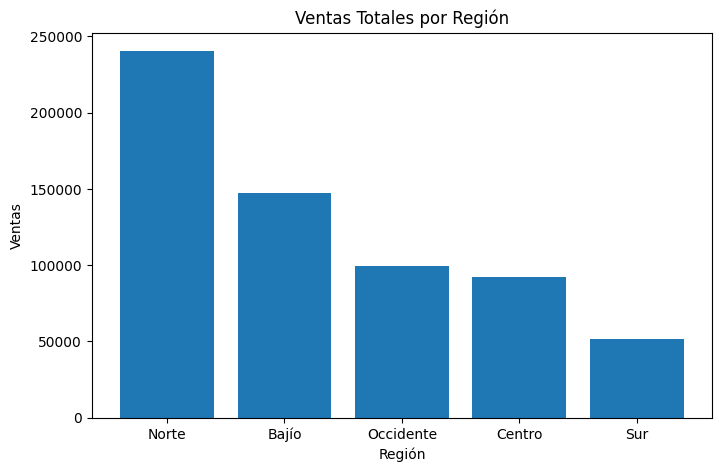

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    ventas_region['region'],
    ventas_region['ventas_totales']
)

plt.title('Ventas Totales por Región')
plt.xlabel('Región')
plt.ylabel('Ventas')

plt.show()

In [21]:
consulta_productos = """
SELECT
    p.producto,
    SUM(f.cantidad) AS total_vendido
FROM fact_ventas f
JOIN dim_producto p
ON f.id_producto = p.id_producto
GROUP BY p.producto
ORDER BY total_vendido DESC;
"""

productos_vendidos = pd.read_sql(
    consulta_productos,
    engine
)

productos_vendidos

,producto,total_vendido
0,Mouse,36
1,Teclado,30
2,Laptop,27
3,Audífonos,26
4,Monitor,21


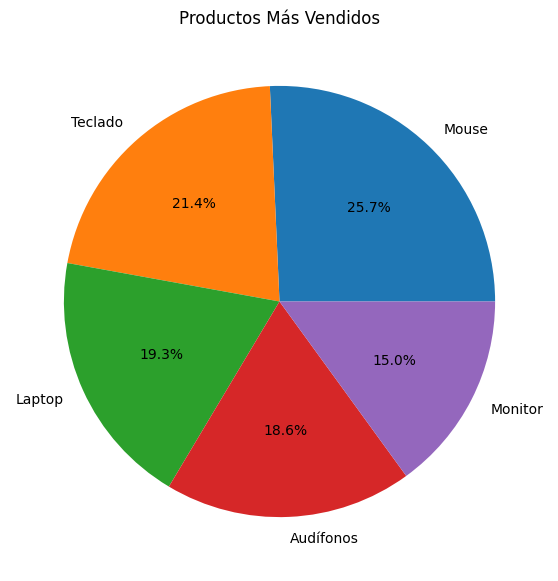

In [22]:
plt.figure(figsize=(7,7))

plt.pie(
    productos_vendidos['total_vendido'],
    labels=productos_vendidos['producto'],
    autopct='%1.1f%%'
)

plt.title('Productos Más Vendidos')

plt.show()

In [23]:
consulta_mes = """
SELECT
    t.mes,
    SUM(f.total_venta) AS ventas
FROM fact_ventas f
JOIN dim_tiempo t
ON f.id_tiempo = t.id_tiempo
GROUP BY t.mes
ORDER BY ventas DESC;
"""

ventas_mes = pd.read_sql(
    consulta_mes,
    engine
)

ventas_mes

,mes,ventas
0,June,136500.0
1,February,123050.0
2,May,113500.0
3,October,59900.0
4,August,45750.0
5,December,36550.0
6,July,30900.0
7,March,23700.0
8,November,22000.0
9,April,19950.0


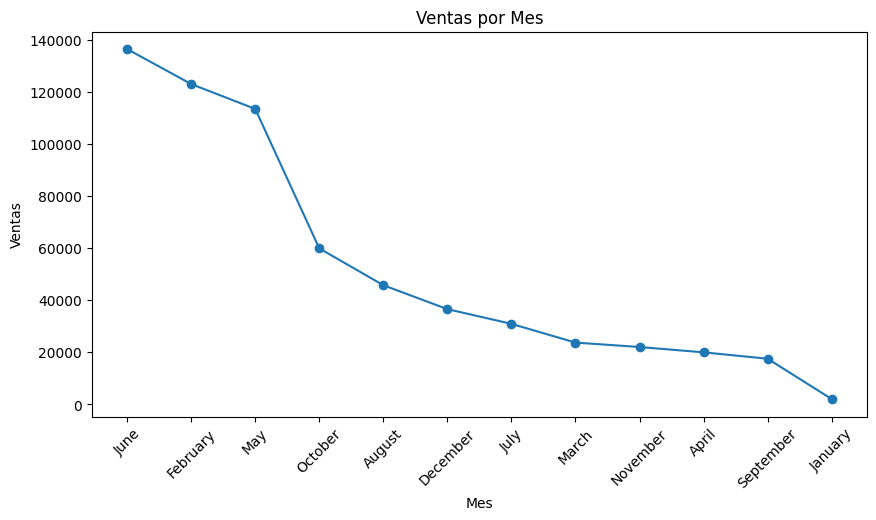

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    ventas_mes['mes'],
    ventas_mes['ventas'],
    marker='o'
)

plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas')

plt.xticks(rotation=45)

plt.show()

#  Validación de Datos Cargados
Mostrar las tablas del Data Warehouse


In [25]:
print("Clientes")
display(pd.read_sql("SELECT * FROM dim_cliente", engine))

print("Productos")
display(pd.read_sql("SELECT * FROM dim_producto", engine))

print("Regiones")
display(pd.read_sql("SELECT * FROM dim_region", engine))

print("Tiempo")
display(pd.read_sql("SELECT * FROM dim_tiempo", engine))

print("Ventas")
display(pd.read_sql("SELECT * FROM fact_ventas LIMIT 10", engine))

Clientes


,id_cliente,nombre,genero,edad
0,1,Giovani,M,25
1,2,Keyla,F,30
2,3,Sandra,F,22
3,4,Adan,M,28
4,5,Martha,F,35


Productos


,id_producto,producto,categoria,precio
0,1,Laptop,Computo,15000.0
1,2,Mouse,Accesorios,250.0
2,3,Teclado,Accesorios,600.0
3,4,Monitor,Computo,8500.0
4,5,Audífonos,Audio,800.0


Regiones


,id_region,region,ciudad
0,1,Norte,Monterrey
1,2,Centro,Ciudad de México
2,3,Sur,Mérida
3,4,Occidente,Guadalajara
4,5,Bajío,Querétaro


Tiempo


,id_tiempo,fecha,mes,anio
0,1,2026-06-30,June,2026
1,2,2026-07-31,July,2026
2,3,2026-08-31,August,2026
3,4,2026-09-30,September,2026
4,5,2026-10-31,October,2026
5,6,2026-11-30,November,2026
6,7,2026-12-31,December,2026
7,8,2027-01-31,January,2027
8,9,2027-02-28,February,2027
9,10,2027-03-31,March,2027


Ventas


,id_venta,id_cliente,id_producto,id_region,id_tiempo,cantidad,total_venta
0,1,5,3,1,6,4,2400.0
1,2,2,5,3,2,2,1600.0
2,3,3,1,5,12,2,30000.0
3,4,5,5,4,1,5,4000.0
4,5,1,4,3,2,3,25500.0
5,6,4,2,3,7,5,1250.0
6,7,2,4,1,4,2,17000.0
7,8,1,3,5,9,2,1200.0
8,9,4,2,5,9,3,750.0
9,10,4,2,1,8,3,750.0


# Conclusiones

Durante esta práctica se desarrolló e implementó un Data Warehouse utilizando PostgreSQL y Python en Jupyter Notebook. Se diseñó un modelo dimensional compuesto por tablas de dimensiones y una tabla de hechos,
permitiendo almacenar información de manera organizada para su posterior análisis.

La utilización de un Data Warehouse facilita la integración de datos y la generación de indicadores que apoyan la toma de decisiones. Mediante consultas SQL y 
herramientas de visualización fue posible identificar patrones de ventas, regiones con mayor rendimiento y productos más demandados.

Esta práctica permitió comprender la importancia de los procesos de almacenamiento, transformación y análisis de datos dentro de un 
entorno empresarial, así como el uso de herramientas modernas para la inteligencia de negocios.